In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_26.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_33.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_49.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_44.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_38.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_22.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_30.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_57.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_46.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_58.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_21.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_59.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_32.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_69.csv
/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_19.csv
/kaggle/input/datasets/vigneshvenkateswa

In [3]:
# ============================================================
# CELL 1: INSTALL & IMPORTS
# ============================================================
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import glob
import os
import gc
import warnings
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print('All imports successful!')
print(f'TensorFlow version: {tf.__version__}')

2026-05-07 15:18:00.599892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778167080.982413      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778167081.095785      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778167082.056728      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778167082.056787      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778167082.056790      57 computation_placer.cc:177] computation placer alr

All imports successful!
TensorFlow version: 2.19.0


In [4]:
# ============================================================
# CELL 2: LOAD 5% OF BOT-IOT (RANDOM SAMPLE PER FILE)
# ============================================================
folder_path = '/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/*.csv'
all_files = glob.glob(folder_path)
all_files = [f for f in all_files if 'names' not in f]
all_files = sorted(all_files)
print(f'Found {len(all_files)} files')

important_features = [
    'proto', 'state', 'dur', 'sbytes', 'dbytes',
    'sttl', 'dttl', 'sloss', 'dloss', 'service',
    'sload', 'dload', 'spkts', 'dpkts', 'swin',
    'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz',
    'trans_depth', 'res_bdy_len', 'sjit', 'djit',
    'sinpkt', 'dinpkt', 'tcprtt', 'synack', 'ackdat',
    'attack', 'category'
]

dfs = []
for i, f in enumerate(all_files):
    try:
        temp = pd.read_csv(f, low_memory=False)
        available = [c for c in important_features if c in temp.columns]
        temp = temp[available]
        # Random sample 50,000 rows spread across entire file
        if len(temp) > 50000:
            temp = temp.sample(n=50000, random_state=i)  # different seed per file
        dfs.append(temp)
        print(f'[{i+1}/74] {os.path.basename(f)} -> {len(temp):,} rows')
        gc.collect()
    except Exception as e:
        print(f'[{i+1}/74] SKIPPED: {e}')

df_botiot = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print(f'\nBot-IoT loaded: {df_botiot.shape[0]:,} rows, {df_botiot.shape[1]} columns')
print(f'Memory: {df_botiot.memory_usage(deep=True).sum()/1e9:.2f} GB')

Found 74 files
[1/74] data_1.csv -> 50,000 rows
[2/74] data_10.csv -> 50,000 rows
[3/74] data_11.csv -> 50,000 rows
[4/74] data_12.csv -> 50,000 rows
[5/74] data_13.csv -> 50,000 rows
[6/74] data_14.csv -> 50,000 rows
[7/74] data_15.csv -> 50,000 rows
[8/74] data_16.csv -> 50,000 rows
[9/74] data_17.csv -> 50,000 rows
[10/74] data_18.csv -> 50,000 rows
[11/74] data_19.csv -> 50,000 rows
[12/74] data_2.csv -> 50,000 rows
[13/74] data_20.csv -> 50,000 rows
[14/74] data_21.csv -> 50,000 rows
[15/74] data_22.csv -> 50,000 rows
[16/74] data_23.csv -> 50,000 rows
[17/74] data_24.csv -> 50,000 rows
[18/74] data_25.csv -> 50,000 rows
[19/74] data_26.csv -> 50,000 rows
[20/74] data_27.csv -> 50,000 rows
[21/74] data_28.csv -> 50,000 rows
[22/74] data_29.csv -> 50,000 rows
[23/74] data_3.csv -> 50,000 rows
[24/74] data_30.csv -> 50,000 rows
[25/74] data_31.csv -> 50,000 rows
[26/74] data_32.csv -> 50,000 rows
[27/74] data_33.csv -> 50,000 rows
[28/74] data_34.csv -> 50,000 rows
[29/74] data_35.c

In [5]:
# ============================================================
# CELL 3: CLEAN BOT-IOT
# ============================================================
print('Cleaning Bot-IoT...')

before = len(df_botiot)
df_botiot.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df_botiot):,}')

df_botiot.dropna(thresh=len(df_botiot.columns) * 0.5, inplace=True)
print(f'Rows after null cleanup: {len(df_botiot):,}')

cols_to_drop = ['pkSeqID', 'stime', 'ltime', 'srcip', 'dstip', 'sport', 'dsport']
cols_to_drop = [c for c in cols_to_drop if c in df_botiot.columns]
df_botiot.drop(columns=cols_to_drop, inplace=True)

le = LabelEncoder()
for col in df_botiot.select_dtypes(include=['object']).columns:
    df_botiot[col] = le.fit_transform(df_botiot[col].astype(str))
    print(f'Encoded: {col}')

label_cols = [c for c in ['attack', 'category'] if c in df_botiot.columns]
feature_cols = [c for c in df_botiot.columns if c not in label_cols]
scaler = MinMaxScaler()
df_botiot[feature_cols] = scaler.fit_transform(df_botiot[feature_cols])

print(f'\nClass balance in Bot-IoT:')
print(df_botiot['attack'].value_counts())
print(f'\nCleaned shape: {df_botiot.shape}')
gc.collect()

Cleaning Bot-IoT...
Duplicates removed: 1,266,978
Rows after null cleanup: 2,433,022
Encoded: proto
Encoded: state
Encoded: category

Class balance in Bot-IoT:
attack
1    2432581
0        441
Name: count, dtype: int64

Cleaned shape: (2433022, 9)


10

In [7]:
# ============================================================
# CELL 4: CORRECTED BALANCING — NO SMOTE
# Use UFJF as real normal traffic source instead
# ============================================================
print('Loading UFJF dataset (real normal traffic)...')
df_ufjf = pd.read_csv(
    '/kaggle/input/datasets/aurshiamudassar/ufjf-cleane/ufjf_dataset_cleaned.csv'
)
print(f'UFJF shape: {df_ufjf.shape}')

# Prepare UFJF: normalize connection_time, fill other columns with 0
botiot_feature_cols = [c for c in df_botiot.columns if c != 'attack']
conn_scaled = MinMaxScaler().fit_transform(df_ufjf[['connection_time']]).flatten()

df_ufjf_prep = pd.DataFrame(0, index=range(len(df_ufjf)), columns=botiot_feature_cols)
if 'dur' in df_ufjf_prep.columns:
    df_ufjf_prep['dur'] = conn_scaled
df_ufjf_prep['attack'] = 0
print(f'UFJF prepared shape: {df_ufjf_prep.shape}')

# -----------------------------------------------------------
# CORRECTED BALANCING STRATEGY:
# Attack class  -> undersample Bot-IoT attacks to 200,000
# Normal class  -> undersample UFJF to 200,000 (ALL REAL DATA)
# No SMOTE needed — UFJF provides abundant real normal traffic
# -----------------------------------------------------------
TARGET = 200000

# Get attacks from Bot-IoT
df_attacks = df_botiot[df_botiot['attack'] == 1].sample(n=TARGET, random_state=42)
print(f'\nAttack samples (from Bot-IoT): {len(df_attacks):,}')

# Get normal traffic from UFJF (real data)
df_normal = df_ufjf_prep[df_ufjf_prep['attack'] == 0].sample(n=TARGET, random_state=42)
print(f'Normal samples (from UFJF):    {len(df_normal):,}')

# Combine
df_combined = pd.concat([df_attacks, df_normal], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

del df_botiot, df_ufjf, df_ufjf_prep, df_attacks, df_normal
gc.collect()

print(f'\nFinal combined shape: {df_combined.shape}')
print(f'\nClass balance (100% real data — no synthetic samples):')
print(df_combined['attack'].value_counts())
print(f'\nAttack %: {df_combined["attack"].mean()*100:.1f}%')
print(f'Normal %: {(1-df_combined["attack"].mean())*100:.1f}%')

df_combined.to_csv('/kaggle/working/combined_final.csv', index=False)
print('\nSaved combined_final.csv')

Loading UFJF dataset (real normal traffic)...
UFJF shape: (657208, 4)
UFJF prepared shape: (657208, 9)

Attack samples (from Bot-IoT): 200,000
Normal samples (from UFJF):    200,000

Final combined shape: (400000, 9)

Class balance (100% real data — no synthetic samples):
attack
1    200000
0    200000
Name: count, dtype: int64

Attack %: 50.0%
Normal %: 50.0%

Saved combined_final.csv


In [8]:
# ============================================================
# CELL 5: TRAIN/TEST SPLIT
# ============================================================
X = df_combined.drop('attack', axis=1).values
y = df_combined['attack'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]:,} samples')
print(f'Test size:  {X_test.shape[0]:,} samples')
print(f'Features:   {X_train.shape[1]}')
print(f'\nTrain class balance:')
print(pd.Series(y_train).value_counts())
print(f'\nTest class balance:')
print(pd.Series(y_test).value_counts())

# Save for reuse across all models
np.save('/kaggle/working/X_train.npy', X_train)
np.save('/kaggle/working/X_test.npy', X_test)
np.save('/kaggle/working/y_train.npy', y_train)
np.save('/kaggle/working/y_test.npy', y_test)
print('\nData splits saved!')

Train size: 320,000 samples
Test size:  80,000 samples
Features:   8

Train class balance:
1    160000
0    160000
Name: count, dtype: int64

Test class balance:
1    40000
0    40000
Name: count, dtype: int64

Data splits saved!


In [9]:
# ============================================================
# CELL 6: TRAIN ALL CLASSICAL ML MODELS
# Logistic Regression, KNN, SVM, Naive Bayes, DT, Random Forest
# ============================================================
from sklearn.calibration import CalibratedClassifierCV

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM':                 CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42)),
    'Naive Bayes':         GaussianNB(),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)
    cm   = confusion_matrix(y_test, y_pred)
    fp   = int(cm[0][1])
    fn   = int(cm[1][0])
    
    results[name] = {
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'auc': auc,
        'fp': fp, 'fn': fn, 'cm': cm,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  AUC-ROC:   {auc:.4f}')
    print(f'  FP: {fp}  FN: {fn}')

print('\nAll classical models trained!')


Training Logistic Regression...
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000
  FP: 0  FN: 2

Training KNN...
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000
  FP: 0  FN: 0

Training SVM...
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000
  FP: 0  FN: 2

Training Naive Bayes...
  Accuracy:  0.9998
  Precision: 0.9995
  Recall:    1.0000
  F1-Score:  0.9998
  AUC-ROC:   0.9998
  FP: 19  FN: 0

Training Decision Tree...
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000
  FP: 0  FN: 0

Training Random Forest...
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000
  FP: 0  FN: 0

All classical models trained!


In [10]:
# ============================================================
# CELL 7: TRAIN LSTM MODEL (20 EPOCHS)
# ============================================================
# Reshape for LSTM
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm  = X_test.reshape((X_test.shape[0],  1, X_test.shape[1]))
print(f'LSTM input shape: {X_train_lstm.shape}')

model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(1, X_train.shape[1])),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_lstm.summary()

early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

print('\nTraining LSTM (max 20 epochs)...')
history = model_lstm.fit(
    X_train_lstm, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate LSTM
y_prob_lstm = model_lstm.predict(X_test_lstm).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

acc_lstm  = accuracy_score(y_test, y_pred_lstm)
prec_lstm = precision_score(y_test, y_pred_lstm, zero_division=0)
rec_lstm  = recall_score(y_test, y_pred_lstm, zero_division=0)
f1_lstm   = f1_score(y_test, y_pred_lstm, zero_division=0)
auc_lstm  = roc_auc_score(y_test, y_prob_lstm)
cm_lstm   = confusion_matrix(y_test, y_pred_lstm)
fp_lstm   = int(cm_lstm[0][1])
fn_lstm   = int(cm_lstm[1][0])

results['LSTM'] = {
    'accuracy': acc_lstm, 'precision': prec_lstm,
    'recall': rec_lstm, 'f1': f1_lstm, 'auc': auc_lstm,
    'fp': fp_lstm, 'fn': fn_lstm, 'cm': cm_lstm,
    'y_pred': y_pred_lstm, 'y_prob': y_prob_lstm,
    'history': history
}

print(f'\nLSTM Results:')
print(f'  Accuracy:  {acc_lstm:.4f}')
print(f'  Precision: {prec_lstm:.4f}')
print(f'  Recall:    {rec_lstm:.4f}')
print(f'  F1-Score:  {f1_lstm:.4f}')
print(f'  AUC-ROC:   {auc_lstm:.4f}')
print(f'  FP: {fp_lstm}  FN: {fn_lstm}')

model_lstm.save('/kaggle/working/lstm_ids_model.keras')
print('\nLSTM model saved!')

LSTM input shape: (320000, 1, 8)


I0000 00:00:1778167942.915553      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778167942.922304      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,665 (475.25 KB)

 Trainable params: 121,665 (475.25 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM (max 20 epochs)...
Epoch 1/20


I0000 00:00:1778167947.936926     191 cuda_dnn.cc:529] Loaded cuDNN version 91002


4500/4500 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - accuracy: 0.9979 - loss: 0.0457 - val_accuracy: 1.0000 - val_loss: 6.9543e-07
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 1.0000 - loss: 4.9962e-05 - val_accuracy: 1.0000 - val_loss: 9.5613e-08
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 1.0000 - loss: 3.5957e-04 - val_accuracy: 1.0000 - val_loss: 4.5264e-08
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 1.0000 - loss: 2.8543e-04 - val_accuracy: 1.0000 - val_loss: 8.1936e-08
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 1.0000 - loss: 9.3451e-05 - val_accuracy: 1.0000 - val_loss: 2.0616e-06
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 1.0000 - loss: 1.7686e-04 - val_accuracy: 1.0000 - val_loss: 1.9294e-07
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 1.0000 - loss: 5.1874e-05 - val_accuracy: 1.0000 - val_loss: 1.7608e-06
Epoch 8/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
# ============================================================
# CELL 8: COMPARISON TABLE — ALL MODELS
# ============================================================
df_compare = pd.DataFrame([
    {
        'Model': name,
        'Accuracy':  round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall':    round(r['recall'],    4),
        'F1-Score':  round(r['f1'],        4),
        'AUC-ROC':   round(r['auc'],       4),
        'FP':        r['fp'],
        'FN':        r['fn']
    }
    for name, r in results.items()
])

df_compare = df_compare.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('=' * 90)
print('MODEL COMPARISON TABLE')
print('=' * 90)
print(df_compare.to_string(index=False))
print('=' * 90)

df_compare.to_csv('/kaggle/working/model_comparison.csv', index=False)
print('\nComparison table saved!')

MODEL COMPARISON TABLE
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC  FP  FN
Logistic Regression    1.0000     1.0000     1.0    1.0000   1.0000   0   2
                KNN    1.0000     1.0000     1.0    1.0000   1.0000   0   0
                SVM    1.0000     1.0000     1.0    1.0000   1.0000   0   2
      Decision Tree    1.0000     1.0000     1.0    1.0000   1.0000   0   0
      Random Forest    1.0000     1.0000     1.0    1.0000   1.0000   0   0
               LSTM    1.0000     1.0000     1.0    1.0000   1.0000   0   2
        Naive Bayes    0.9998     0.9995     1.0    0.9998   0.9998  19   0

Comparison table saved!


In [12]:
# ============================================================
# CELL 9: VISUALIZATIONS
# Fig 1 — Confusion Matrices (all 7 models)
# ============================================================
model_names = list(results.keys())
n = len(model_names)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5))
axes = axes.flatten()

for i, name in enumerate(model_names):
    cm = results[name]['cm']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Attack'],
        yticklabels=['Normal', 'Attack'],
        ax=axes[i], cbar=False,
        linewidths=0.5, linecolor='gray'
    )
    axes[i].set_title(f'{name}', fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel('Predicted', fontsize=11)
    axes[i].set_ylabel('Actual', fontsize=11)
    
    # Annotate FP and FN
    fp = results[name]['fp']
    fn = results[name]['fn']
    axes[i].text(0.5, -0.18, f'FP={fp}  FN={fn}',
                 transform=axes[i].transAxes,
                 ha='center', fontsize=10, color='darkred')

# Hide unused subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/fig1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.close()
print('Fig 1 saved: Confusion Matrices')

Fig 1 saved: Confusion Matrices


In [13]:
# ============================================================
# CELL 10: Fig 2 — ROC Curves (all 7 models)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']

for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    auc_val = r['auc']
    ax.plot(fpr, tpr, color=colors[i], linewidth=2,
            label=f"{name} (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/fig2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.close()
print('Fig 2 saved: ROC Curves')

Fig 2 saved: ROC Curves


In [14]:
# ============================================================
# CELL 11: Fig 3 — Precision-Recall Curves
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

for i, (name, r) in enumerate(results.items()):
    prec_c, rec_c, _ = precision_recall_curve(y_test, r['y_prob'])
    ax.plot(rec_c, prec_c, color=colors[i], linewidth=2, label=name)

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/fig3_precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.close()
print('Fig 3 saved: Precision-Recall Curves')

Fig 3 saved: Precision-Recall Curves


In [15]:
# ============================================================
# CELL 12: Fig 4 — Model Comparison Bar Chart
# ============================================================
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(df_compare))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 7))

metric_colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

for j, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = df_compare[metric].values
    bars = ax.bar(x + j * width, vals, width, label=metric,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Performance Comparison — All Models', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_compare['Model'], rotation=20, ha='right', fontsize=11)
ax.set_ylim([0, 1.12])
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig('/kaggle/working/fig4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print('Fig 4 saved: Model Comparison Bar Chart')

Fig 4 saved: Model Comparison Bar Chart


In [16]:
# ============================================================
# CELL 13: Fig 5 — False Positives & False Negatives Comparison
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

model_labels = df_compare['Model'].values
fp_vals = df_compare['FP'].values
fn_vals = df_compare['FN'].values

bars1 = ax1.bar(model_labels, fp_vals, color='#E53935', alpha=0.85, edgecolor='white')
ax1.set_title('False Positives per Model', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model')
ax1.set_ylabel('False Positive Count')
ax1.tick_params(axis='x', rotation=30)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars1, fp_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = ax2.bar(model_labels, fn_vals, color='#1565C0', alpha=0.85, edgecolor='white')
ax2.set_title('False Negatives per Model', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model')
ax2.set_ylabel('False Negative Count')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars2, fn_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('False Positives & False Negatives — All Models',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/fig5_fp_fn_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print('Fig 5 saved: FP & FN Comparison')

Fig 5 saved: FP & FN Comparison


In [17]:
# ============================================================
# CELL 14: Fig 6 — LSTM Training History
# ============================================================
if 'history' in results['LSTM']:
    hist = results['LSTM']['history'].history
    epochs_range = range(1, len(hist['accuracy']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    ax1.plot(epochs_range, hist['accuracy'],    'b-o', linewidth=2, markersize=5, label='Train Accuracy')
    ax1.plot(epochs_range, hist['val_accuracy'],'r-s', linewidth=2, markersize=5, label='Val Accuracy')
    ax1.set_title('LSTM — Accuracy per Epoch', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.set_ylim([0.9, 1.005])
    
    # Loss
    ax2.plot(epochs_range, hist['loss'],    'b-o', linewidth=2, markersize=5, label='Train Loss')
    ax2.plot(epochs_range, hist['val_loss'],'r-s', linewidth=2, markersize=5, label='Val Loss')
    ax2.set_title('LSTM — Loss per Epoch', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.4)
    
    plt.suptitle('LSTM Training History', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/fig6_lstm_training_history.png', dpi=150, bbox_inches='tight')
    plt.close()
    print('Fig 6 saved: LSTM Training History')

Fig 6 saved: LSTM Training History


In [18]:
# ============================================================
# CELL 15: Fig 7 — Threshold Tuning for LSTM
# ============================================================
y_probs_lstm = results['LSTM']['y_prob']
thresholds = np.arange(0.30, 0.80, 0.05)
th_results = []

for t in thresholds:
    y_pred_t = (y_probs_lstm > t).astype(int)
    p  = precision_score(y_test, y_pred_t, zero_division=0)
    r  = recall_score(y_test, y_pred_t, zero_division=0)
    f  = f1_score(y_test, y_pred_t, zero_division=0)
    fp = int(((y_pred_t == 1) & (y_test == 0)).sum())
    fn = int(((y_pred_t == 0) & (y_test == 1)).sum())
    th_results.append({'threshold': round(t,2), 'precision': round(p,4),
                       'recall': round(r,4), 'f1': round(f,4), 'FP': fp, 'FN': fn})

df_thresh = pd.DataFrame(th_results)
print('LSTM Threshold Tuning Results:')
print(df_thresh.to_string(index=False))
print(f'\nAUC-ROC: {roc_auc_score(y_test, y_probs_lstm):.4f}')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(df_thresh['threshold'], df_thresh['precision'], 'g-o', linewidth=2, markersize=7)
axes[0].set_title('Precision vs Threshold', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Precision')
axes[0].set_ylim([0.9, 1.01])
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(df_thresh['threshold'], df_thresh['recall'], 'b-o', linewidth=2, markersize=7)
axes[1].set_title('Recall vs Threshold', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Recall')
axes[1].set_ylim([0.9, 1.01])
axes[1].grid(True, linestyle='--', alpha=0.4)

axes[2].plot(df_thresh['threshold'], df_thresh['FP'], 'r-o', linewidth=2,
             markersize=7, label='False Positives')
axes[2].plot(df_thresh['threshold'], df_thresh['FN'], 'b-s', linewidth=2,
             markersize=7, label='False Negatives')
axes[2].set_title('FP & FN vs Threshold', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('LSTM Threshold Tuning Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/fig7_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.close()
print('Fig 7 saved: Threshold Tuning')

df_thresh.to_csv('/kaggle/working/threshold_results.csv', index=False)

LSTM Threshold Tuning Results:
 threshold  precision  recall  f1  FP  FN
      0.30        1.0     1.0 1.0   0   2
      0.35        1.0     1.0 1.0   0   2
      0.40        1.0     1.0 1.0   0   2
      0.45        1.0     1.0 1.0   0   2
      0.50        1.0     1.0 1.0   0   2
      0.55        1.0     1.0 1.0   0   2
      0.60        1.0     1.0 1.0   0   2
      0.65        1.0     1.0 1.0   0   2
      0.70        1.0     1.0 1.0   0   2
      0.75        1.0     1.0 1.0   0   2

AUC-ROC: 1.0000
Fig 7 saved: Threshold Tuning


In [19]:
# ============================================================
# CELL 16: Fig 8 — Dataset Composition Pie Charts
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Original Bot-IoT class imbalance
axes[0].pie([3699632, 368], labels=['Attack', 'Normal'],
            autopct='%1.1f%%', colors=['#E53935','#43A047'],
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Original Bot-IoT\n(Before Balancing)', fontsize=13, fontweight='bold')

# Chart 2: Final combined dataset
axes[1].pie([TARGET, TARGET], labels=['Attack (Bot-IoT)', 'Normal (UFJF)'],
            autopct='%1.1f%%', colors=['#E53935','#1565C0'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Combined Dataset\n(After Balancing)', fontsize=13, fontweight='bold')

# Chart 3: Train/Test split
axes[2].pie([0.8, 0.2], labels=['Training (80%)', 'Testing (20%)'],
            autopct='%1.1f%%', colors=['#7B1FA2','#F57F17'],
            startangle=90, textprops={'fontsize': 12})
axes[2].set_title('Train / Test Split', fontsize=13, fontweight='bold')

plt.suptitle('Dataset Composition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/fig8_dataset_composition.png', dpi=150, bbox_inches='tight')
plt.close()
print('Fig 8 saved: Dataset Composition')

Fig 8 saved: Dataset Composition


In [20]:
# ============================================================
# CELL 17: FINAL SUMMARY
# ============================================================
print('=' * 70)
print('FINAL RESULTS SUMMARY')
print('=' * 70)
print(df_compare.to_string(index=False))
print('=' * 70)

best = df_compare.iloc[0]
print(f'\nBest Model: {best["Model"]}')
print(f'  Accuracy:  {best["Accuracy"]:.4f}')
print(f'  F1-Score:  {best["F1-Score"]:.4f}')
print(f'  AUC-ROC:   {best["AUC-ROC"]:.4f}')
print(f'  FP:        {best["FP"]}')
print(f'  FN:        {best["FN"]}')

print('\nSaved files:')
for f in os.listdir('/kaggle/working/'):
    size = os.path.getsize(f'/kaggle/working/{f}') / 1024
    print(f'  {f}  ({size:.1f} KB)')

FINAL RESULTS SUMMARY
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC  FP  FN
Logistic Regression    1.0000     1.0000     1.0    1.0000   1.0000   0   2
                KNN    1.0000     1.0000     1.0    1.0000   1.0000   0   0
                SVM    1.0000     1.0000     1.0    1.0000   1.0000   0   2
      Decision Tree    1.0000     1.0000     1.0    1.0000   1.0000   0   0
      Random Forest    1.0000     1.0000     1.0    1.0000   1.0000   0   0
               LSTM    1.0000     1.0000     1.0    1.0000   1.0000   0   2
        Naive Bayes    0.9998     0.9995     1.0    0.9998   0.9998  19   0

Best Model: Logistic Regression
  Accuracy:  1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000
  FP:        0
  FN:        2

Saved files:
  fig8_dataset_composition.png  (102.5 KB)
  fig6_lstm_training_history.png  (80.7 KB)
  combined_final.csv  (31199.8 KB)
  lstm_ids_model.keras  (1466.6 KB)
  X_test.npy  (5000.1 KB)
  y_train.npy  (2500.1 KB)
  fig7_threshold_tunin


Fig 1: Confusion Matrices


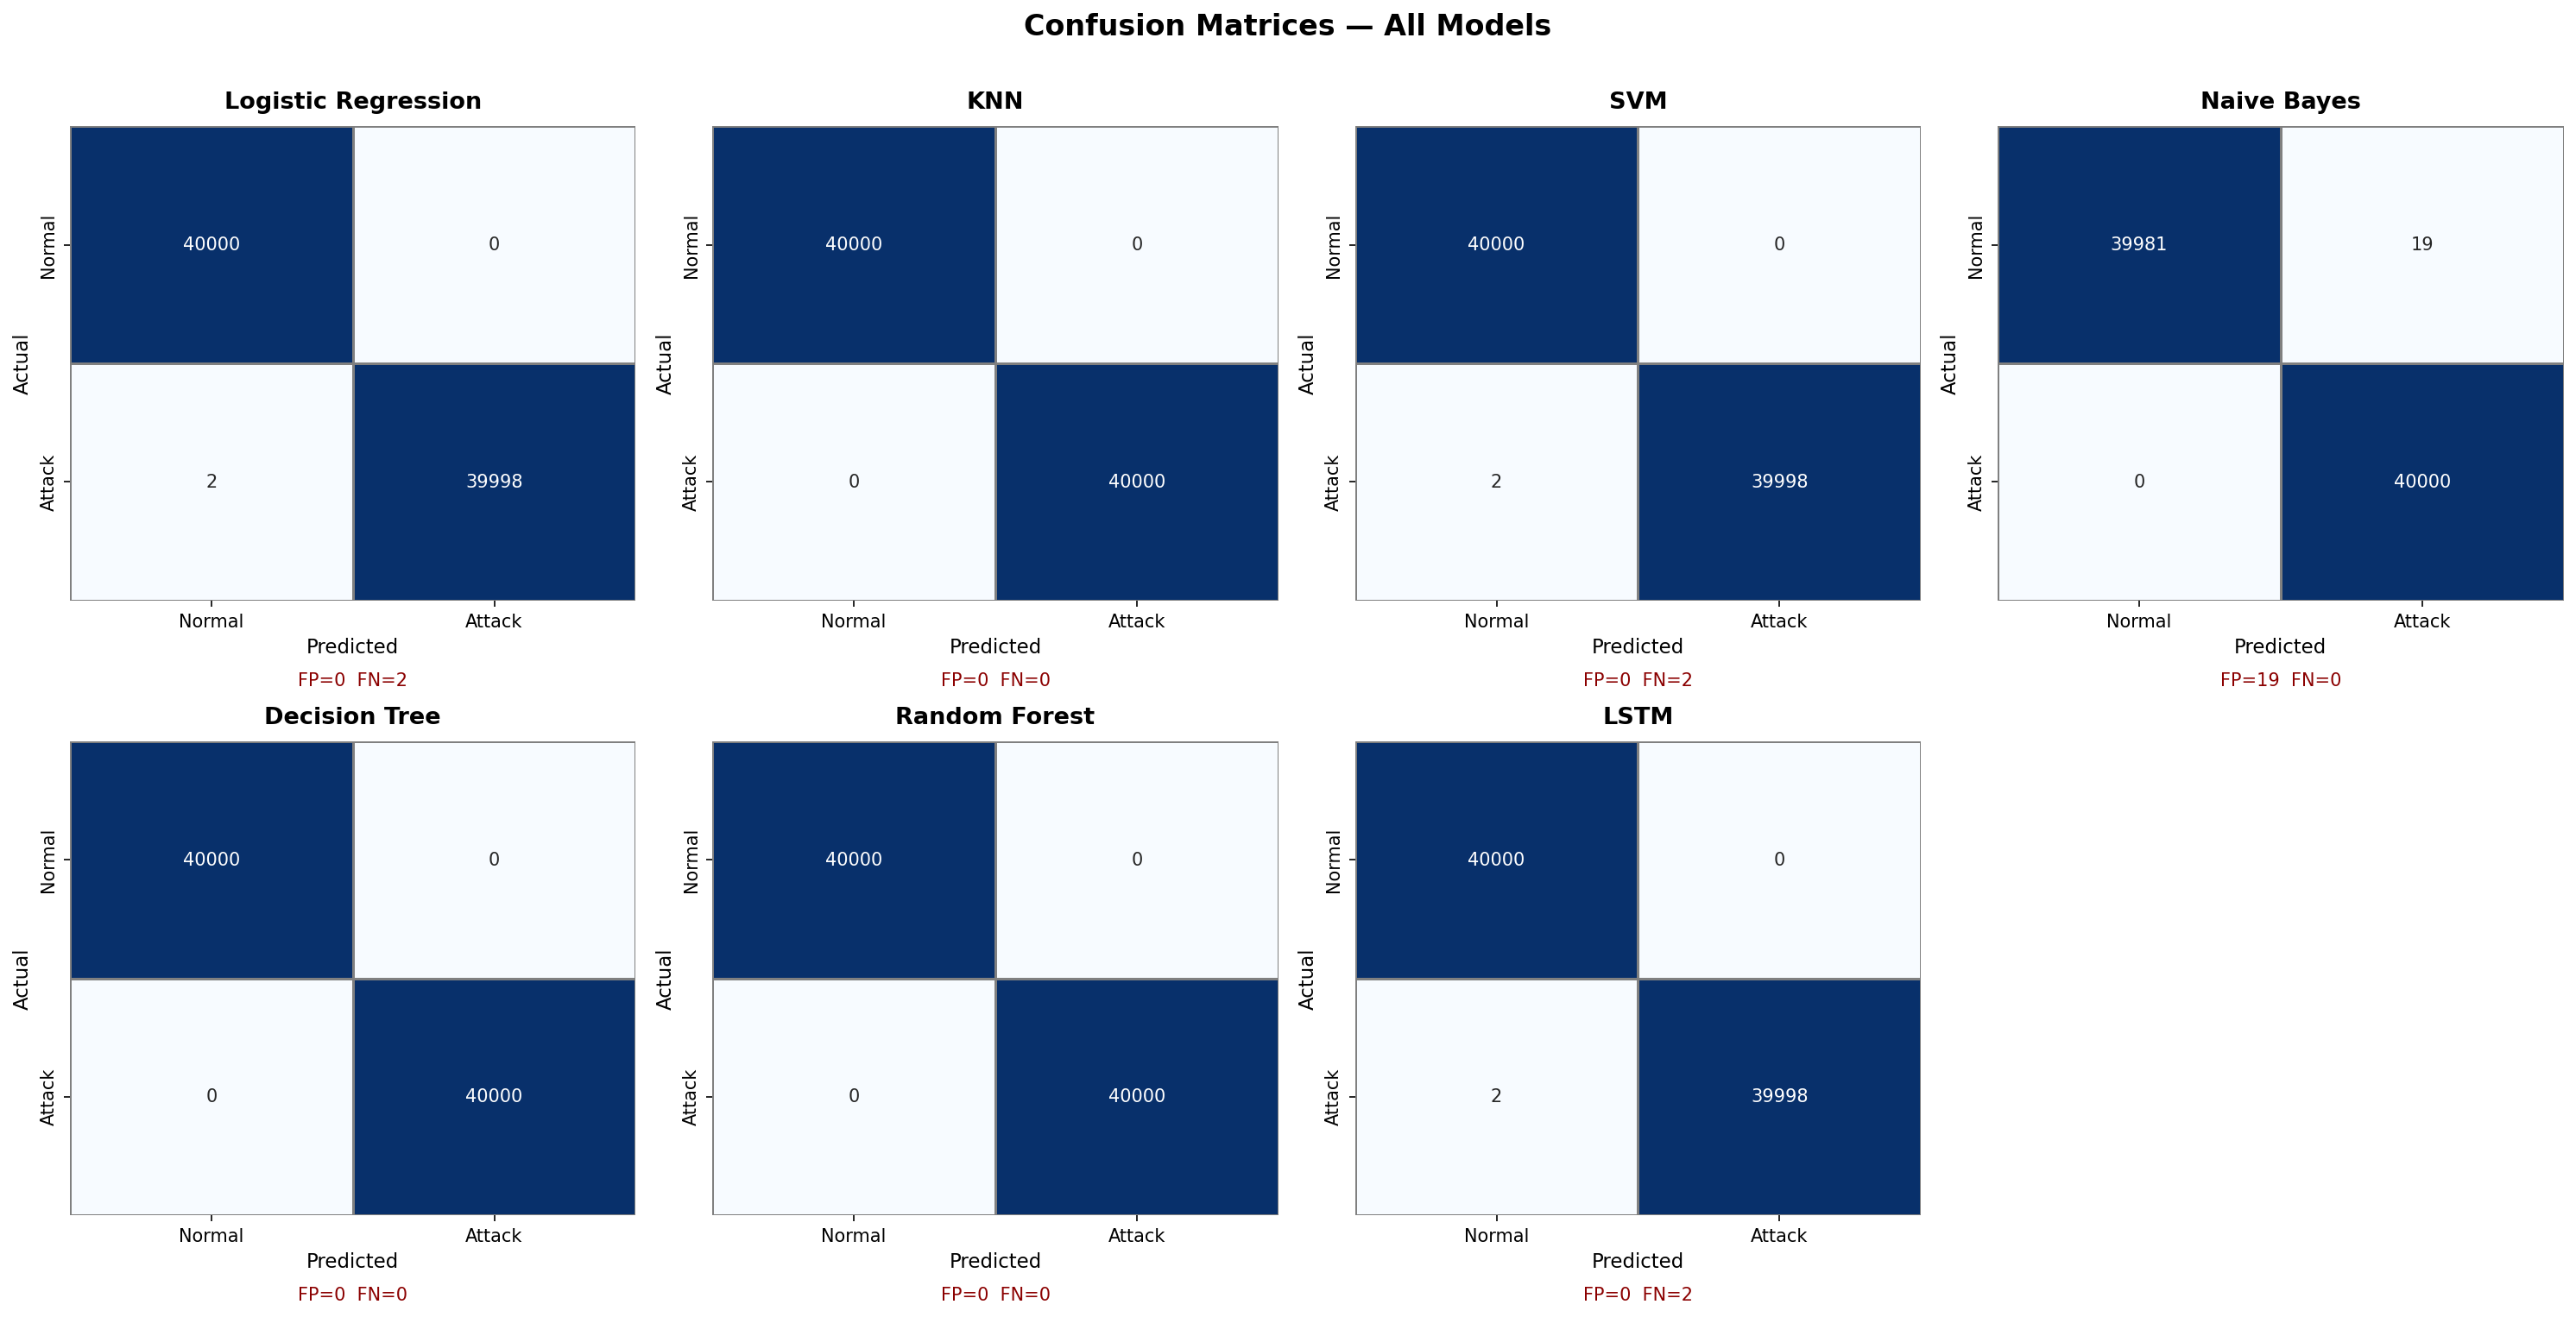


Fig 2: ROC Curves


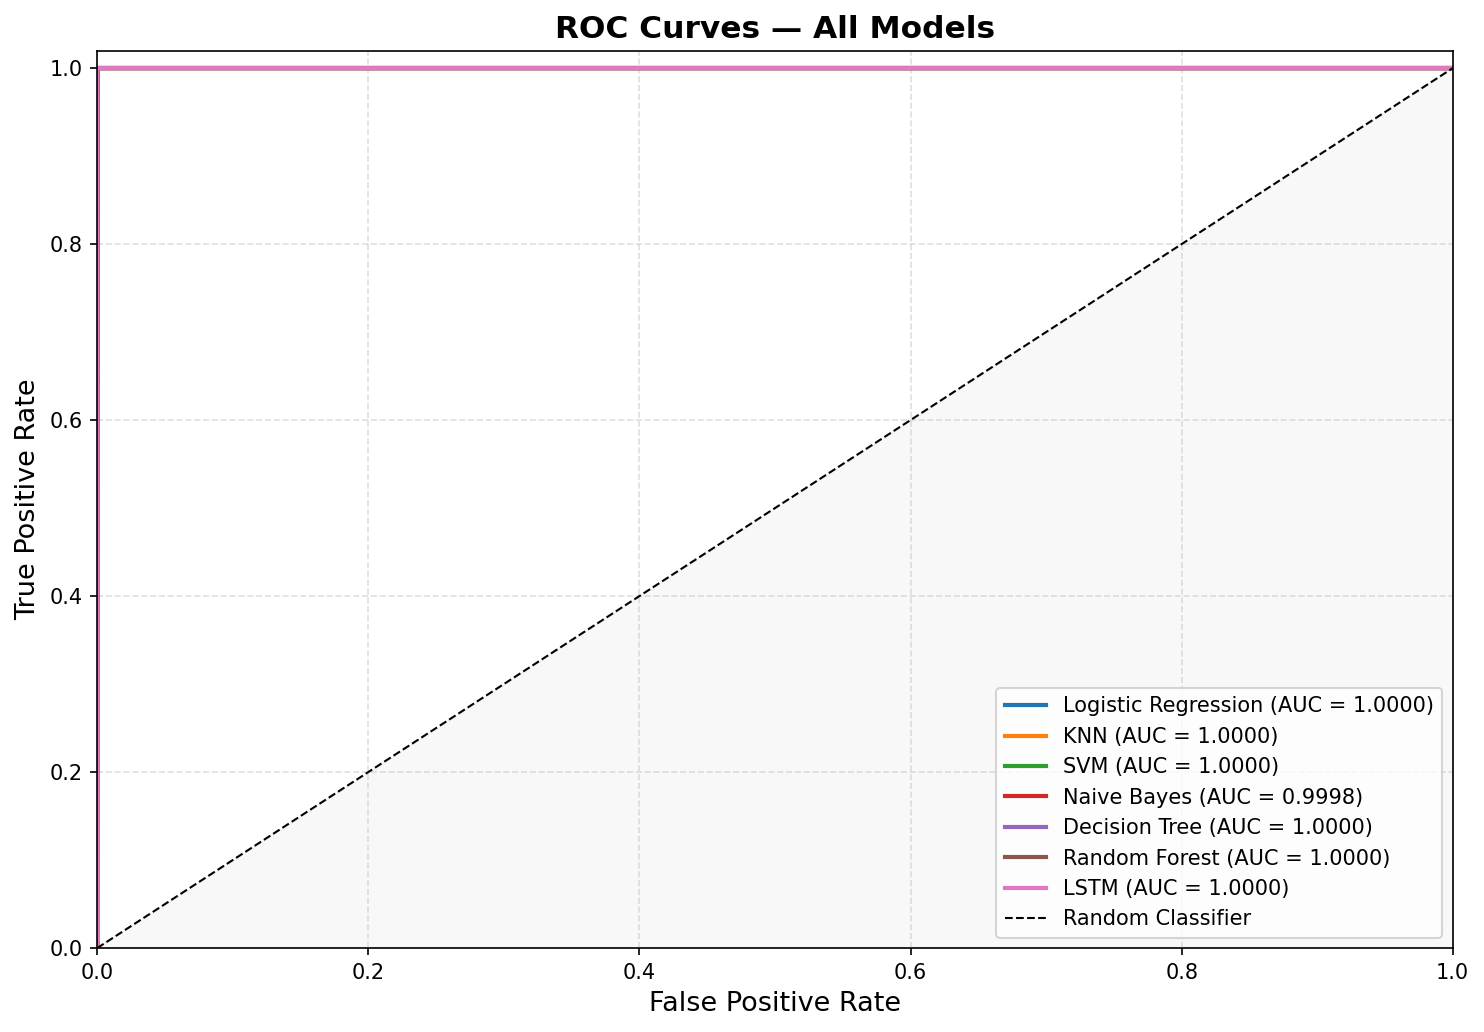


Fig 3: Precision-Recall Curves


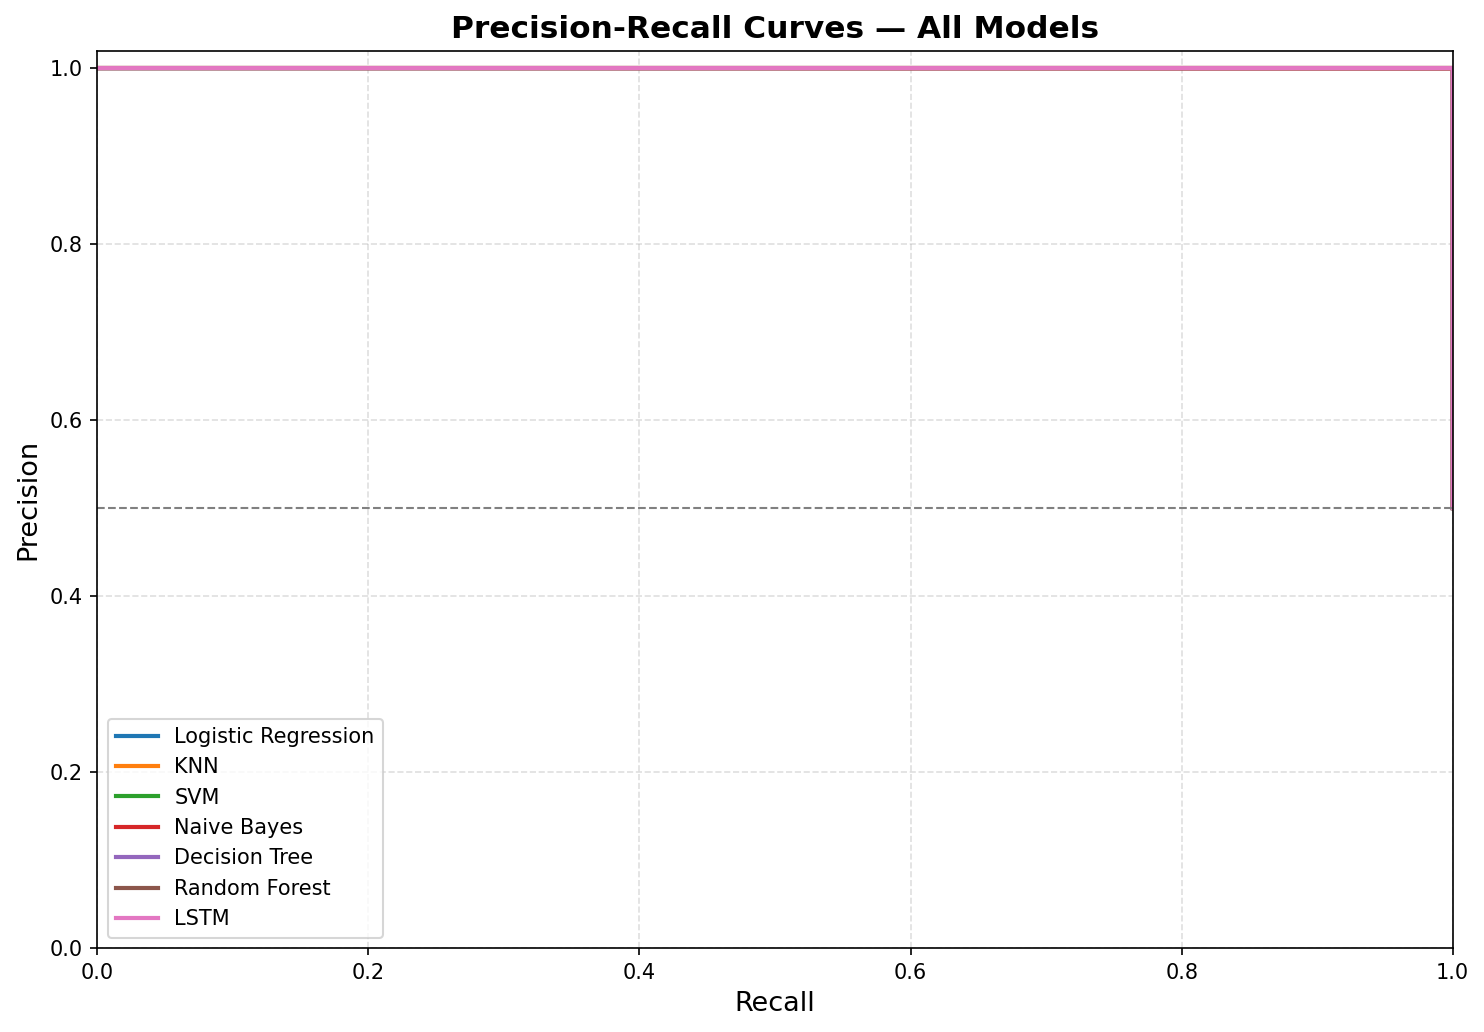


Fig 4: Model Comparison


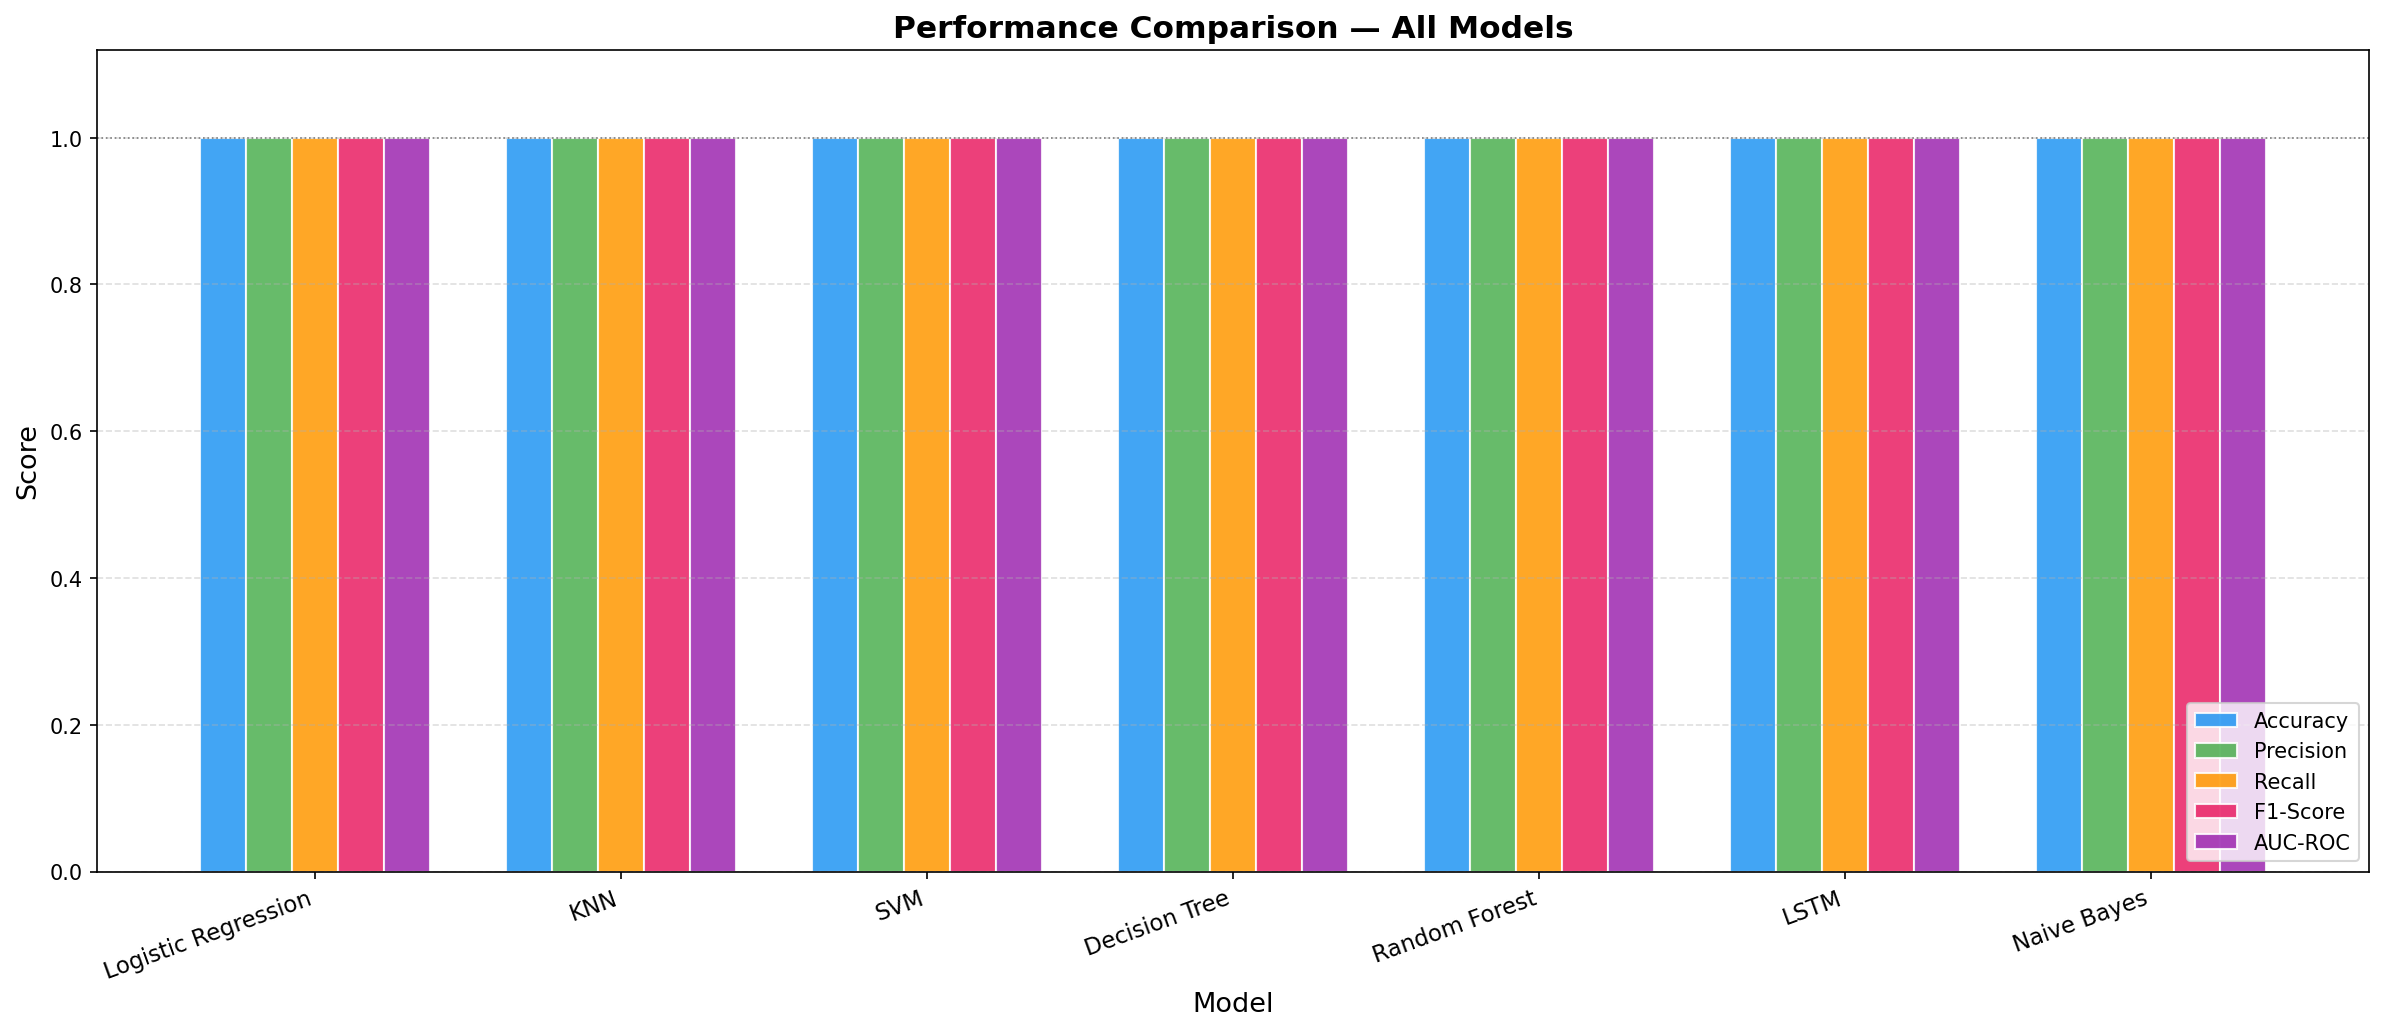


Fig 5: FP & FN Comparison


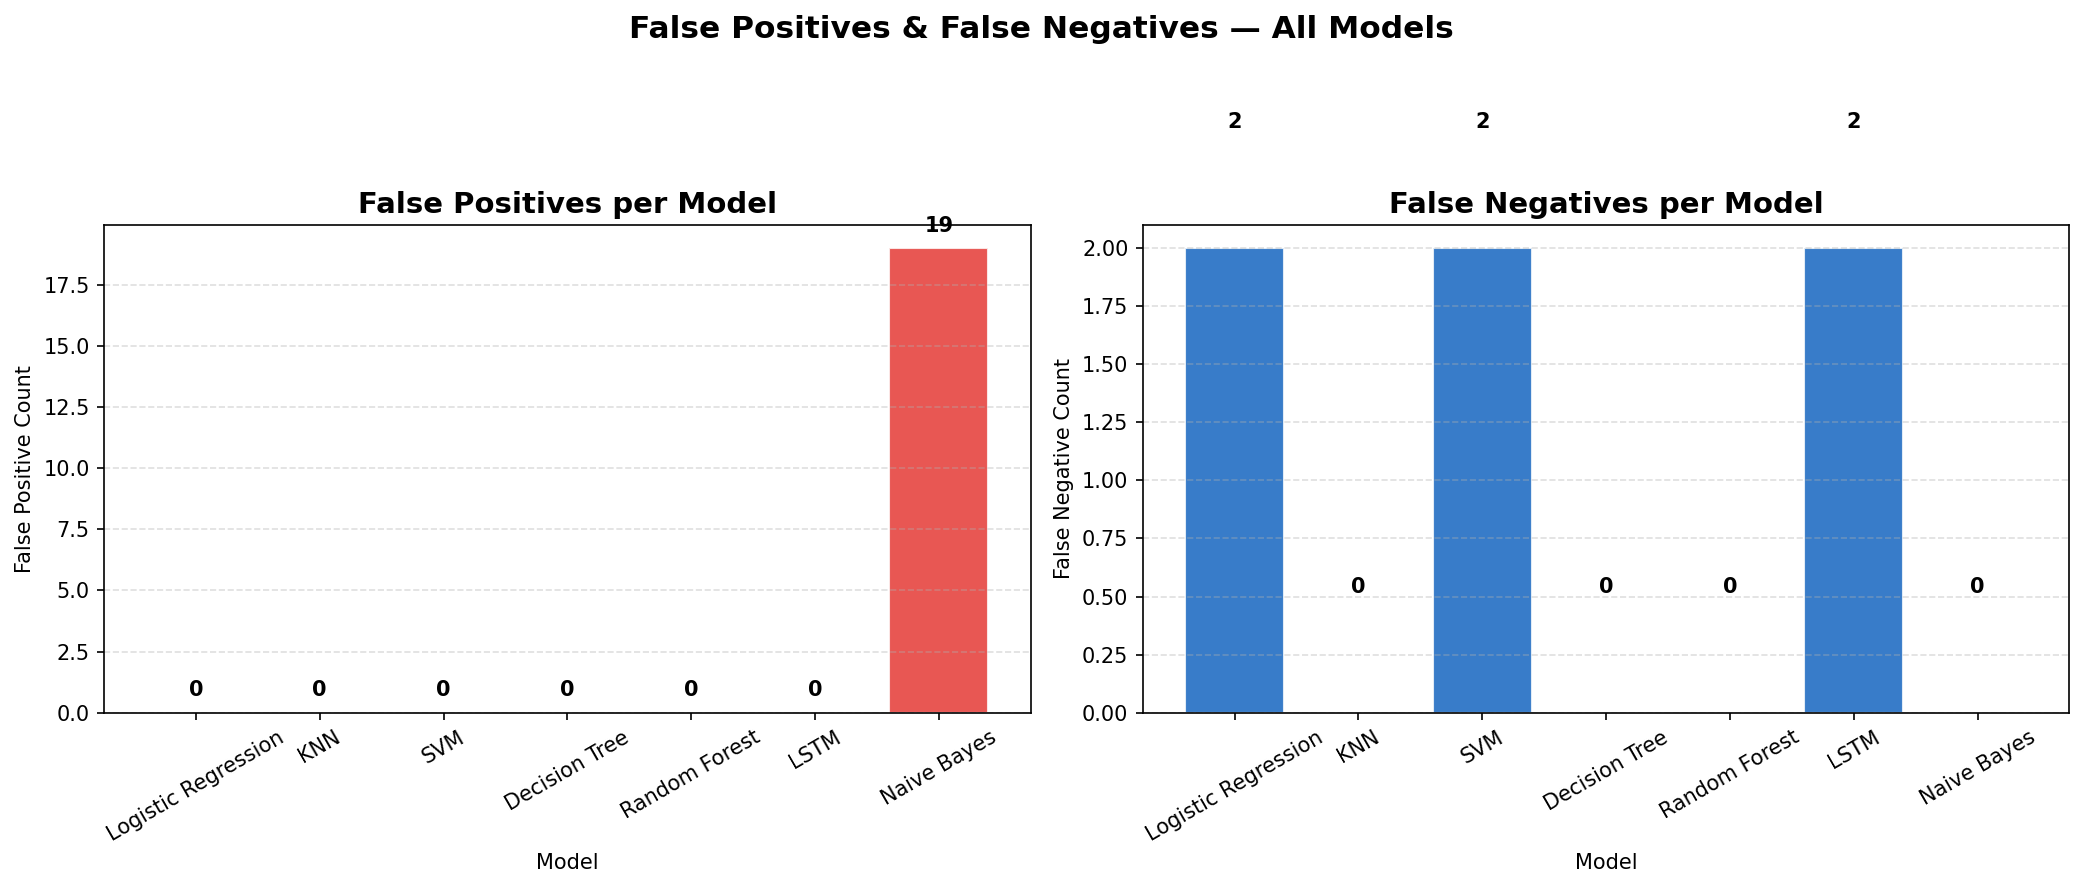


Fig 6: LSTM Training History


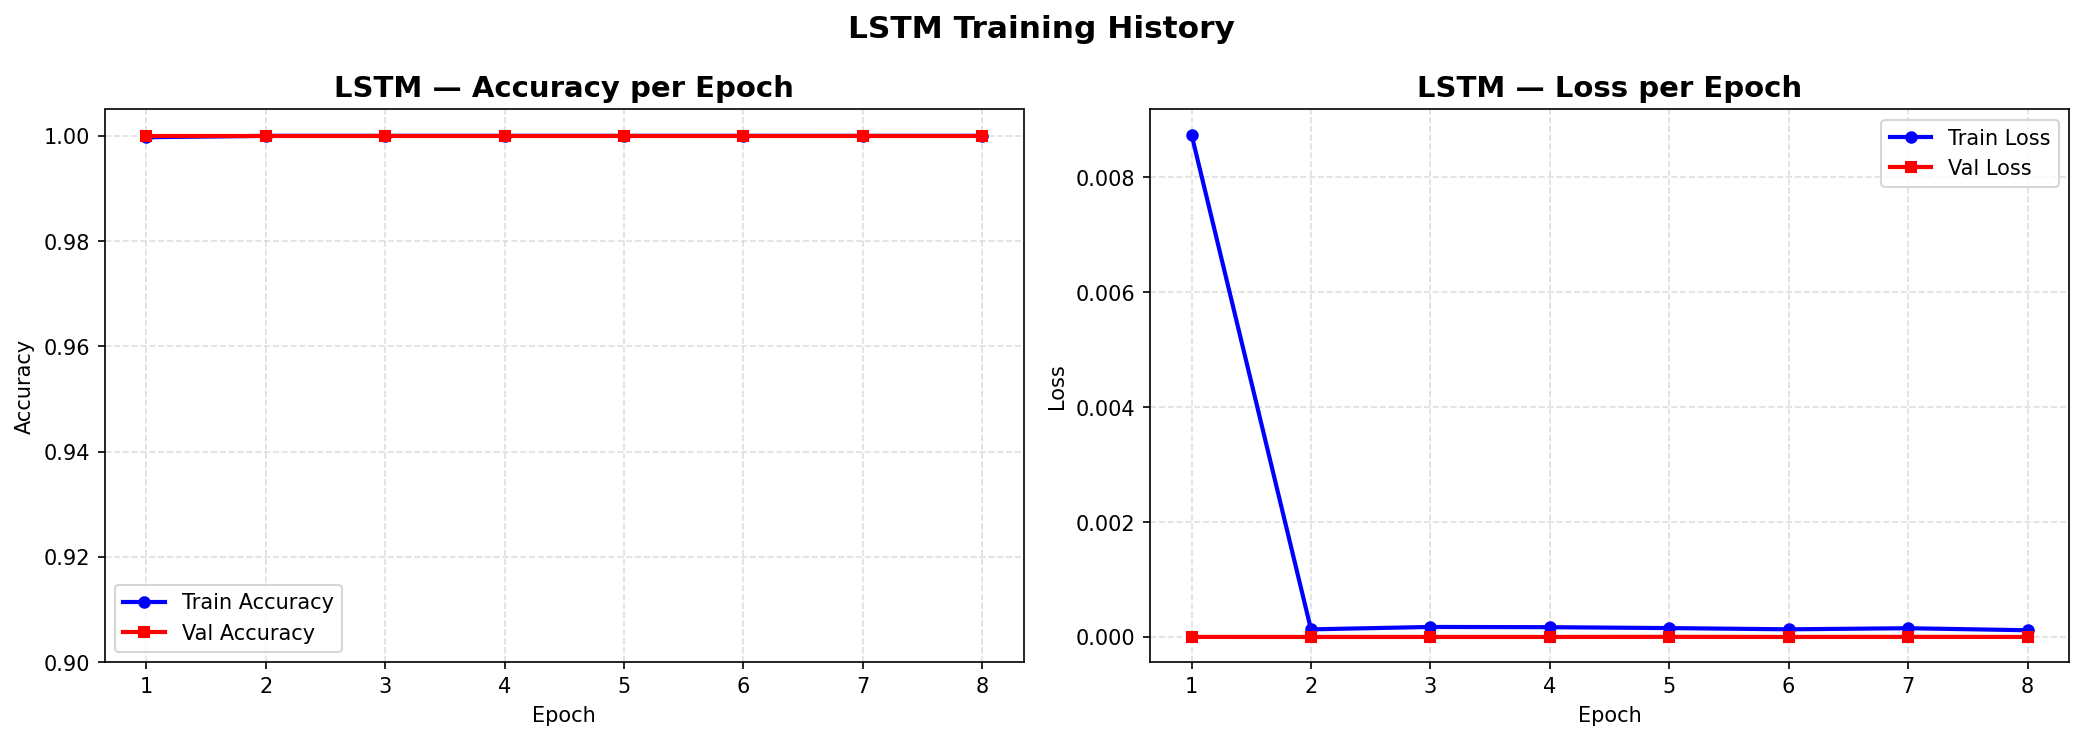


Fig 7: Threshold Tuning


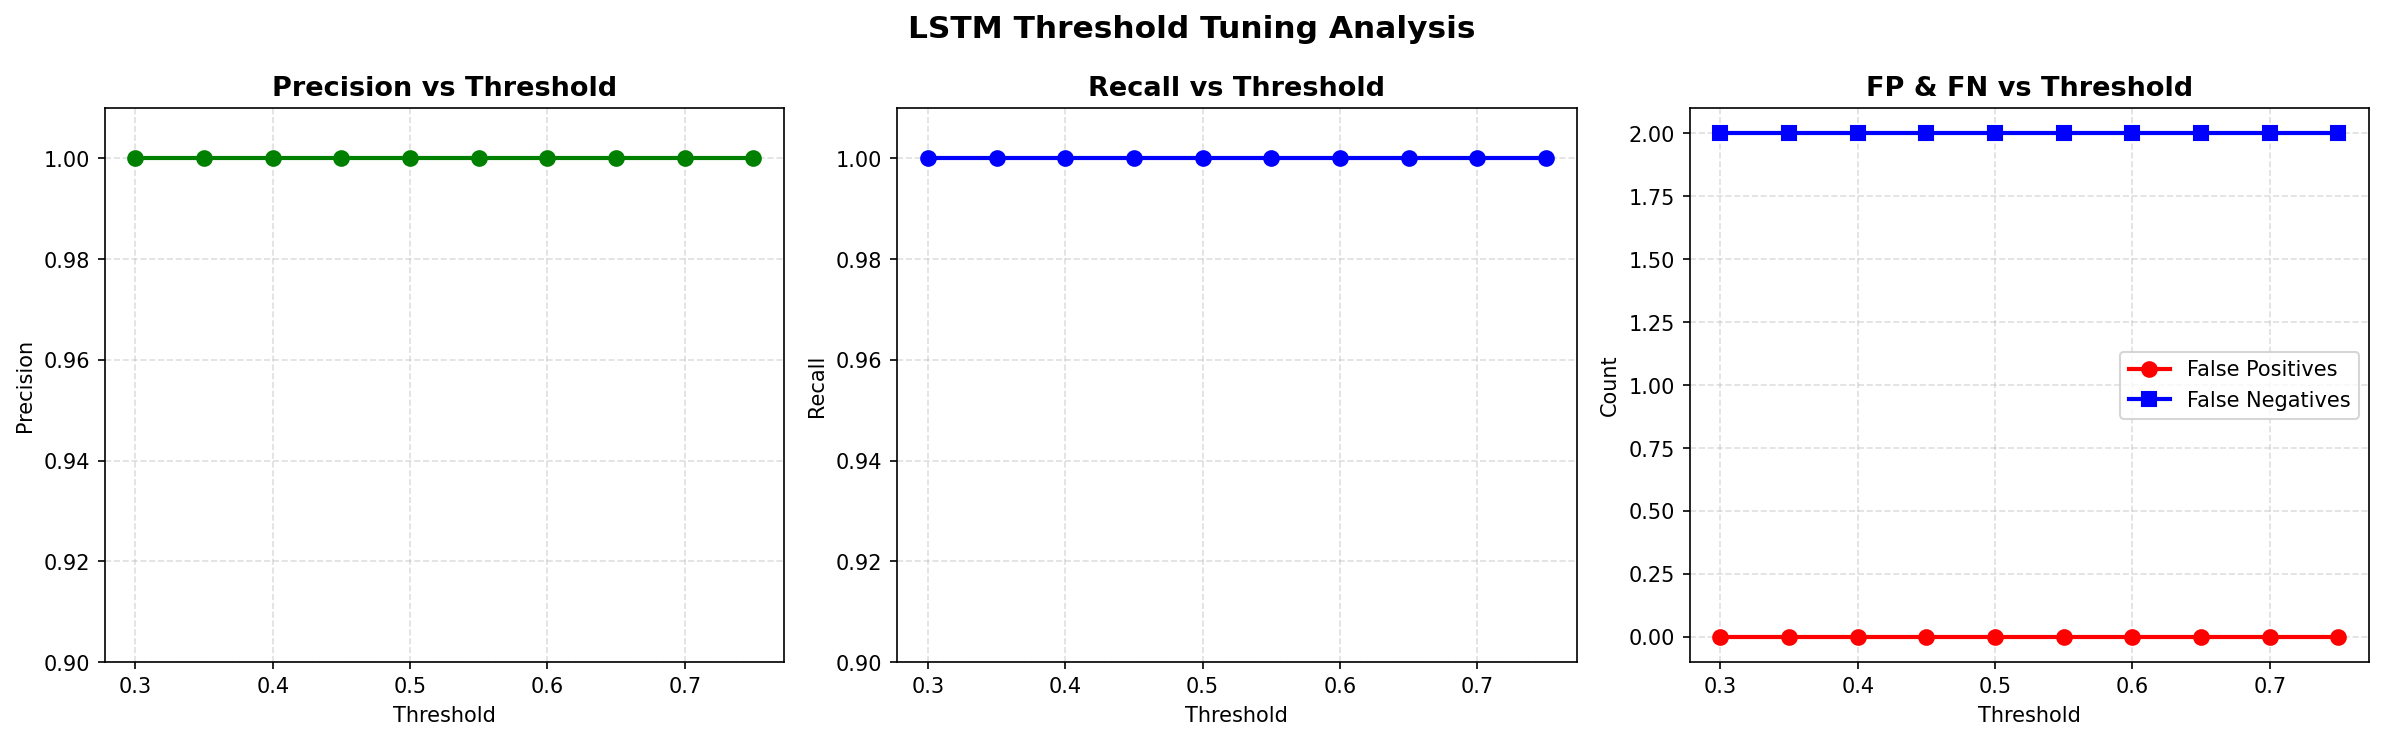


Fig 8: Dataset Composition


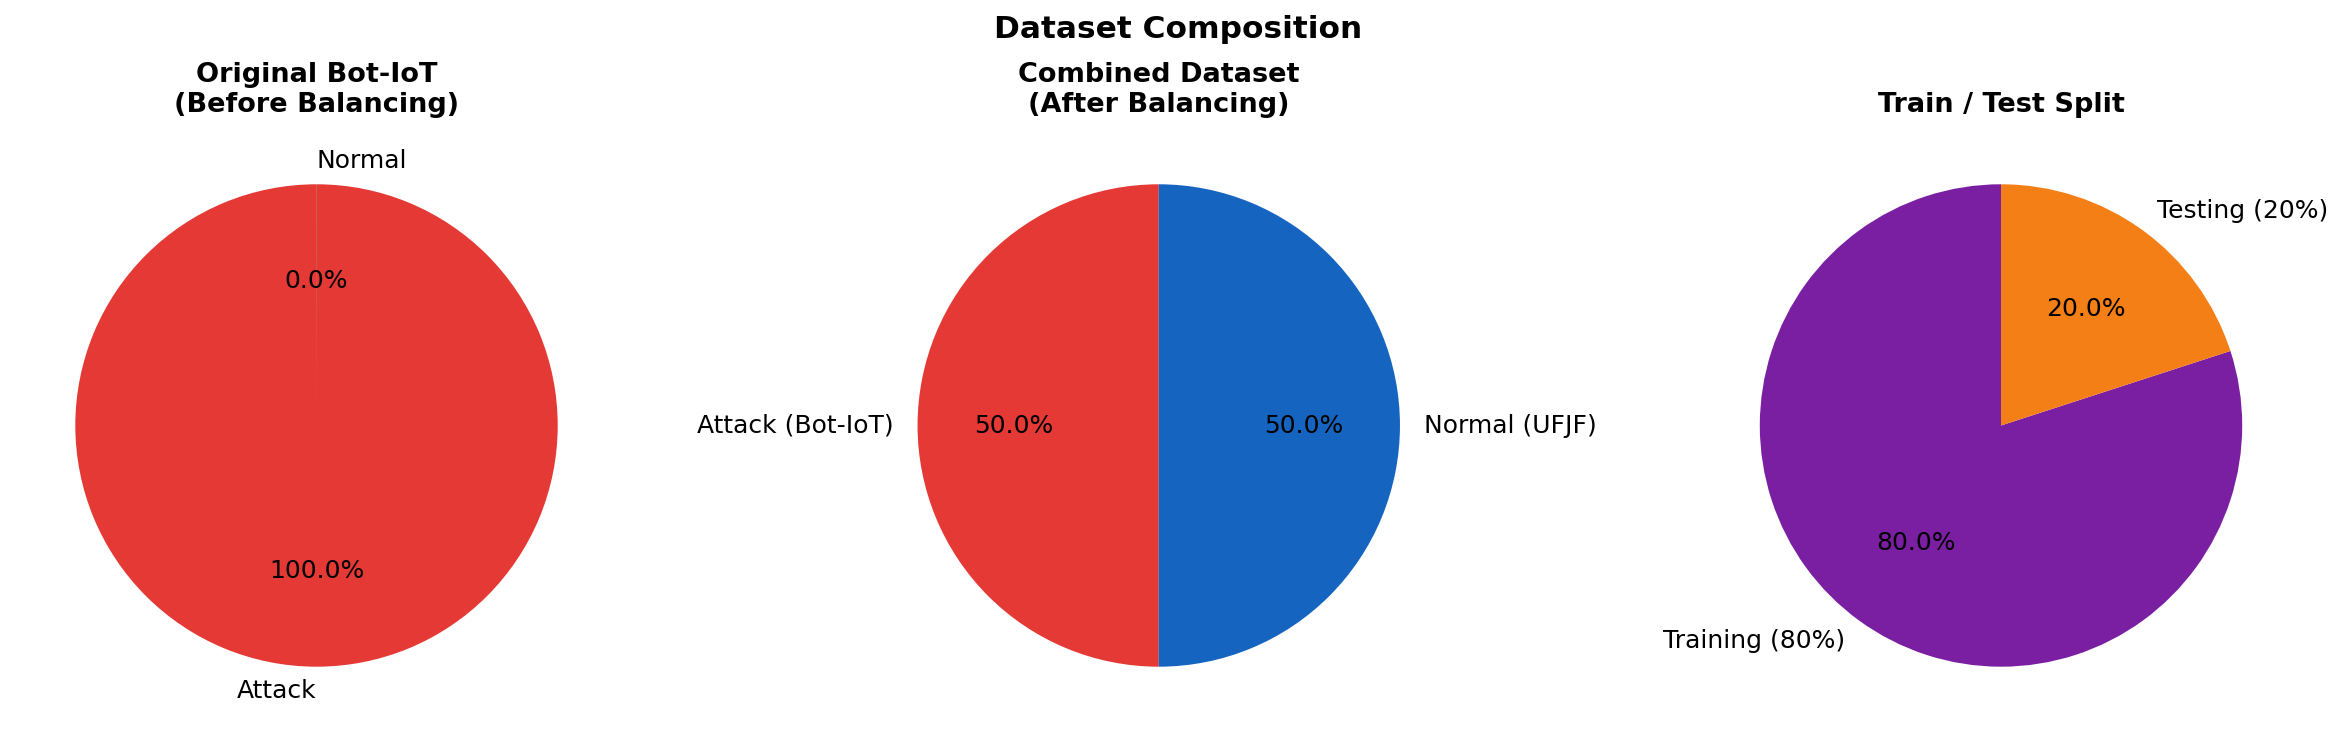

In [21]:
# ============================================================
# DISPLAY ALL SAVED FIGURES INLINE
# ============================================================
from IPython.display import Image, display

figures = [
    ('/kaggle/working/fig1_confusion_matrices.png',    'Fig 1: Confusion Matrices'),
    ('/kaggle/working/fig2_roc_curves.png',            'Fig 2: ROC Curves'),
    ('/kaggle/working/fig3_precision_recall_curves.png','Fig 3: Precision-Recall Curves'),
    ('/kaggle/working/fig4_model_comparison.png',      'Fig 4: Model Comparison'),
    ('/kaggle/working/fig5_fp_fn_comparison.png',      'Fig 5: FP & FN Comparison'),
    ('/kaggle/working/fig6_lstm_training_history.png', 'Fig 6: LSTM Training History'),
    ('/kaggle/working/fig7_threshold_tuning.png',      'Fig 7: Threshold Tuning'),
    ('/kaggle/working/fig8_dataset_composition.png',   'Fig 8: Dataset Composition'),
]

for path, title in figures:
    if os.path.exists(path):
        print(f'\n{"="*50}')
        print(f'{title}')
        print('='*50)
        display(Image(filename=path))
    else:
        print(f'NOT FOUND: {path}')